# FYP Data Exploration - Adaptive Difficulty System

**Project**: AI-Powered Adaptive Difficulty for Mini-Games  
**Author**: Izzat  
**Dataset**: GameplayData.csv (Single Difficulty + User Feedback)

## Overview
This notebook explores gameplay session data collected from two mini-games (Fighting & Racing) where participants play at a single difficulty level and provide feedback on whether it was "Too Easy" or "Too Hard". This feedback serves as ground truth labels for training a Random Forest model to predict difficulty adjustments.

## New Data Collection Methodology
- **Single difficulty level** per session (no Easy/Medium/Hard comparison)
- **User feedback** as explicit labels: "TooEasy" or "TooHard"
- **Objective**: Train model to recommend "make harder" or "make easier" based on performance metrics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv(r'../../Data/Raw/GameplayData.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Dataset loaded: 160 rows, 25 columns
Date range: 1/2/2026 19:26 to 7/2/2026 9:58


## 1. Dataset Structure

In [2]:
# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nTotal Sessions: {len(df)}")
print(f"Unique Players: {df['playerID'].nunique()}")
print(f"Game Types: {df['gameType'].unique()}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print("\n" + "="*60)

# Show first few rows
df.head(10)

DATASET OVERVIEW

Total Sessions: 160
Unique Players: 80
Game Types: ['Fighting' 'Racing']

Column Names:
['sessionID', 'playerID', 'gameType', 'difficultyLevel', 'sessionDuration', 'score', 'deaths', 'completed', 'timestamp', 'victory', 'combosExecuted', 'perfectDodges', 'hitsDealt', 'hitsTaken', 'playerAccuracy', 'avgReactionTime', 'lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime', 'collisions', 'maxSpeed', 'avgSpeed', 'consistency', 'feedback']



,sessionID,playerID,gameType,difficultyLevel,sessionDuration,score,deaths,completed,timestamp,victory,...,avgReactionTime,lapsCompleted,bestLapTime,avgLapTime,totalRaceTime,collisions,maxSpeed,avgSpeed,consistency,feedback
0,9ce3b181-5421-4501-a8bb-31ccd9f62020,1,Fighting,Medium,33.13,2950,0,True,11/1/2026 16:54,True,...,0.551105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TooEasy
1,cebdef88-7877-43ef-bc35-70692e4fe106,1,Racing,Medium,122.30,600,0,True,11/1/2026 17:01,NaN,...,NaN,3.0,39.57999,40.76645,122.29930,10.0,40.0,37.64244,0.967751,Balanced
2,88a8e63b-a9f2-4ab3-ae56-ebd5e65ea589,2,Fighting,Medium,40.53,469,1,True,11/1/2026 17:08,False,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TooHard
3,b35ad4ab-920c-4e46-ab6d-33d7b6154708,2,Racing,Medium,177.94,50,0,True,11/1/2026 17:16,NaN,...,NaN,3.0,57.81998,59.31197,177.93590,21.0,40.0,26.76684,0.979516,TooHard
4,955585c6-2018-495f-90c7-7c5c5954ec12,3,Fighting,Medium,37.81,512,1,True,11/1/2026 17:24,False,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Balanced
5,19977a02-8ed7-4f59-b508-c3cf2c141081,3,Racing,Medium,49.41,0,1,False,11/1/2026 17:30,NaN,...,NaN,1.0,43.47988,43.47988,49.40567,32.0,40.0,35.97134,1.000000,TooHard
6,db6875ff-4fe2-4427-a8bf-7c6f3c05151c,4,Fighting,Medium,28.85,2256,0,True,11/1/2026 19:49,True,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TooEasy
7,73c4a339-5116-494e-915b-2a2a862944d2,4,Racing,Medium,118.32,0,0,True,11/1/2026 19:55,NaN,...,NaN,3.0,38.87999,39.43989,118.31970,28.0,40.0,38.56696,0.987248,TooHard
8,03dcb765-5754-43ba-a80d-b86ce3719771,5,Fighting,Medium,23.93,3614,0,True,12/1/2026 0:19,True,...,0.260920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TooEasy
9,6edde4c1-3337-4b3b-936a-bc0581922621,5,Racing,Medium,126.52,0,0,True,12/1/2026 0:26,NaN,...,NaN,3.0,40.77998,42.17327,126.51980,25.0,40.0,36.73416,0.967730,TooHard


Text(0.5, 1.0, 'Number of Sessions Per Game Type')

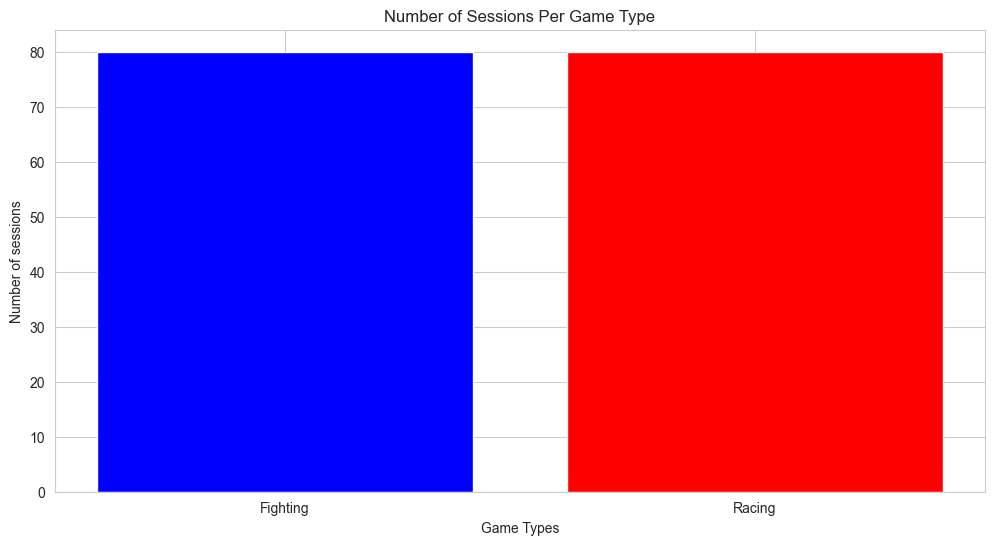

In [8]:
gameTypes = df['gameType'].unique()

total_racing_sessions = (df['gameType'] == 'Racing').sum()
total_fighting_sessions = (df['gameType'] == 'Fighting').sum()
total_sessions = [total_fighting_sessions, total_racing_sessions]

plt.bar(gameTypes, total_sessions, color=['blue', 'red'])

plt.xlabel('Game Types')
plt.ylabel('Number of sessions')
plt.title('Number of Sessions Per Game Type')


In [24]:
# Data types and missing values
print("DATA QUALITY CHECK")
print("="*60)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

DATA QUALITY CHECK

Data Types:
sessionID           object
playerID             int64
gameType            object
difficultyLevel     object
sessionDuration    float64
score                int64
deaths               int64
completed             bool
timestamp           object
victory             object
combosExecuted     float64
perfectDodges      float64
hitsDealt          float64
hitsTaken          float64
playerAccuracy     float64
avgReactionTime    float64
lapsCompleted      float64
bestLapTime        float64
avgLapTime         float64
totalRaceTime      float64
collisions         float64
maxSpeed           float64
avgSpeed           float64
consistency        float64
feedback            object
dtype: object

Missing Values:
victory            80
combosExecuted     80
perfectDodges      80
hitsDealt          80
hitsTaken          80
playerAccuracy     80
avgReactionTime    80
lapsCompleted      80
bestLapTime        80
avgLapTime         80
totalRaceTime      80
collisions         8

## 2. Core Session Metrics

Analysis of universal metrics collected across both game types.

In [25]:
# Basic statistics for core metrics
core_metrics = ['sessionDuration', 'score', 'deaths', 'completed']
print("CORE METRICS SUMMARY")
print("="*60)
print(df[core_metrics].describe())

# Completion rate
completion_rate = df['completed'].mean() * 100
print(f"\nOverall Completion Rate: {completion_rate:.1f}%")

CORE METRICS SUMMARY
       sessionDuration        score      deaths
count       160.000000   160.000000  160.000000
mean         70.728062  1181.756250    0.300000
std          47.199584  1014.819994    0.459696
min           7.580000     0.000000    0.000000
25%          33.472500   479.500000    0.000000
50%          48.105000   800.000000    0.000000
75%         117.237500  2217.000000    1.000000
max         336.310000  3614.000000    1.000000

Overall Completion Rate: 89.4%


## 3. User Feedback Distribution (Ground Truth Labels)

**Critical for ML Training**: This is our target variable showing how participants felt about the difficulty.

PLAYER FEEDBACK DISTRIBUTION

Overall Feedback:
  Balanced: 62 sessions (38.8%)
  TooHard: 54 sessions (33.8%)
  TooEasy: 44 sessions (27.5%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_29840\3009720377.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='feedback', ax=axes[0], palette=['#2c30a0', "#2ca02c", "#a02c2c"])


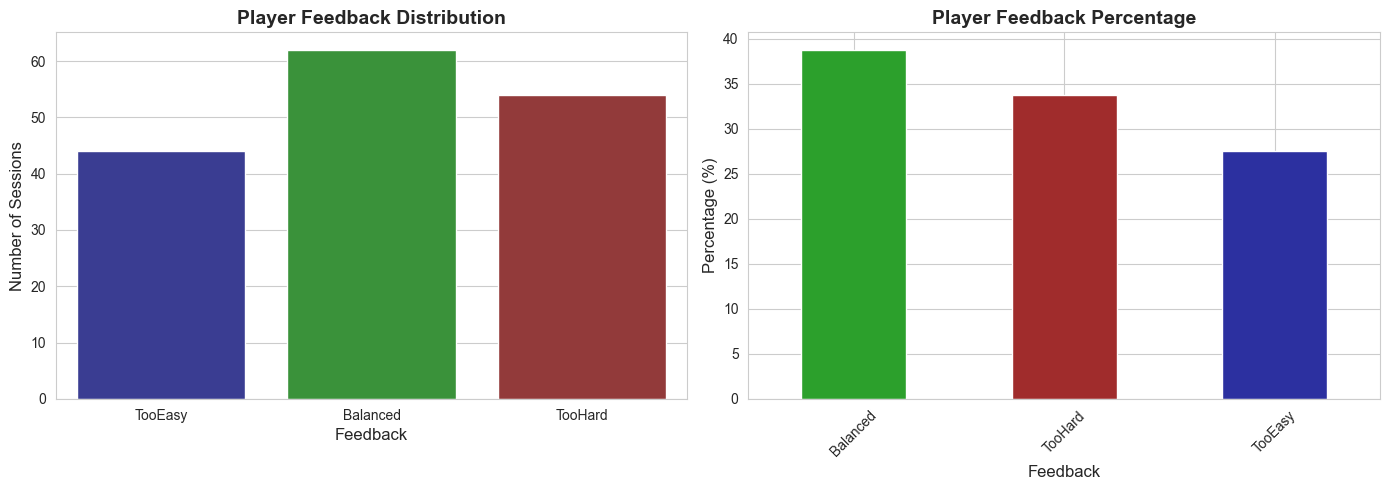


Class Balance Check:
  Majority class: 38.8%
  Minority class: 27.5%
  Imbalance ratio: 1.41:1


In [13]:
# Check if feedback column exists
if 'feedback' in df.columns:
    print("PLAYER FEEDBACK DISTRIBUTION")
    print("="*60)
    
    # Overall distribution
    feedback_counts = df['feedback'].value_counts()
    feedback_pct = df['feedback'].value_counts(normalize=True) * 100
    
    print("\nOverall Feedback:")
    for label in feedback_counts.index:
        count = feedback_counts[label]
        pct = feedback_pct[label]
        print(f"  {label}: {count} sessions ({pct:.1f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    sns.countplot(data=df, x='feedback', ax=axes[0], palette=['#2c30a0', "#2ca02c", "#a02c2c"])
    axes[0].set_title('Player Feedback Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Feedback', fontsize=12)
    axes[0].set_ylabel('Number of Sessions', fontsize=12)
    
    # Percentage plot
    feedback_pct.plot(kind='bar', ax=axes[1], color=["#2ca02c", "#a02c2c", '#2c30a0'])
    axes[1].set_title('Player Feedback Percentage', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Feedback', fontsize=12)
    axes[1].set_ylabel('Percentage (%)', fontsize=12)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Class balance check
    max_class = feedback_pct.max()
    min_class = feedback_pct.min()
    imbalance_ratio = max_class / min_class
    print(f"\nClass Balance Check:")
    print(f"  Majority class: {max_class:.1f}%")
    print(f"  Minority class: {min_class:.1f}%")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 2:
        print(f"  ⚠️  WARNING: Significant class imbalance detected!")
        print(f"     Consider collecting more '{feedback_pct.idxmin()}' samples")
else:
    print("⚠️  WARNING: 'feedback' column not found!")
    print("Available columns:", df.columns.tolist())

FEEDBACK DISTRIBUTION BY GAME TYPE

Percentage by Game Type:
feedback  Balanced  TooEasy  TooHard
gameType                            
Fighting      45.0     28.7     26.2
Racing        32.5     26.2     41.2


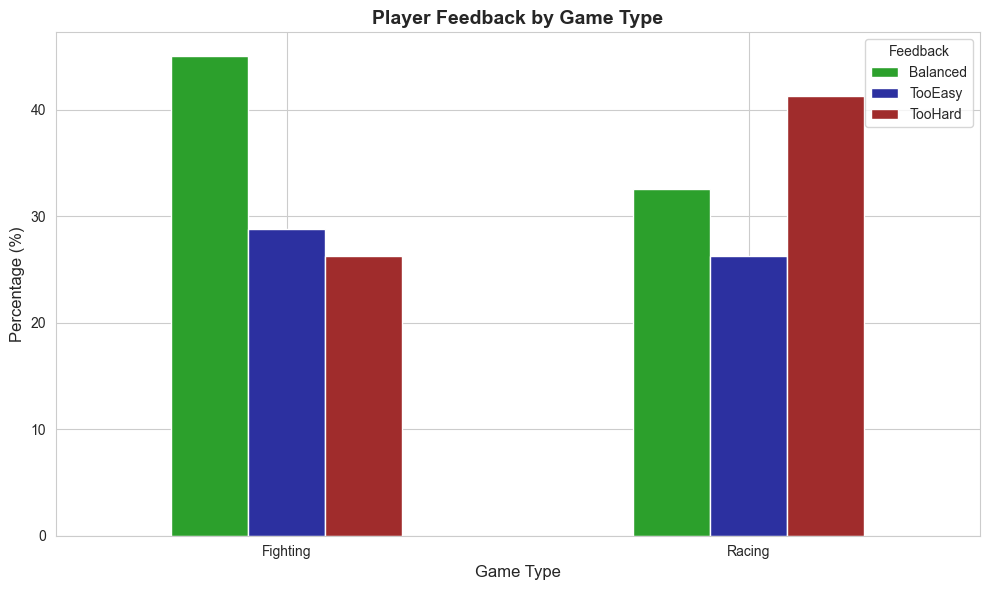


Chi-square test for independence:
  Chi-square statistic: 4.3705
  P-value: 0.1125
  Feedback distribution is similar across game types (p >= 0.05)


In [14]:
if 'feedback' in df.columns:
    print("FEEDBACK DISTRIBUTION BY GAME TYPE")
    print("="*60)
    
    # Cross-tabulation
    feedback_by_game = pd.crosstab(df['gameType'], df['feedback'], normalize='index') * 100
    print("\nPercentage by Game Type:")
    print(feedback_by_game.round(1))
    
    # Visualization
    feedback_by_game.plot(kind='bar', figsize=(10, 6), color=["#2ca02c", '#2c30a0', "#a02c2c"])
    plt.title('Player Feedback by Game Type', fontsize=14, fontweight='bold')
    plt.xlabel('Game Type', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.legend(title='Feedback', fontsize=10)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Statistical test
    contingency = pd.crosstab(df['gameType'], df['feedback'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    print(f"\nChi-square test for independence:")
    print(f"  Chi-square statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  ✓ Feedback distribution differs significantly between game types (p < 0.05)")
    else:
        print(f"  Feedback distribution is similar across game types (p >= 0.05)")

## 4. Game-Specific Analysis

### 4.1 Fighting Game Metrics

In [28]:
# Filter fighting game data
fighting_df = df[df['gameType'] == 'Fighting'].copy()

print("FIGHTING GAME ANALYSIS")
print("="*60)
print(f"Total Fighting Sessions: {len(fighting_df)}")

# Fighting-specific metrics
fighting_metrics = [col for col in fighting_df.columns if col in [
    'victory', 'combosExecuted', 'perfectDodges', 'hitsDealt', 
    'hitsTaken', 'playerAccuracy', 'avgReactionTime'
]]

if fighting_metrics:
    print(f"\nFighting-Specific Metrics: {fighting_metrics}")
    print(fighting_df[fighting_metrics].describe())
    
    # Victory rate
    if 'victory' in fighting_df.columns:
        victory_rate = fighting_df['victory'].mean() * 100
        print(f"\nVictory Rate: {victory_rate:.1f}%")

FIGHTING GAME ANALYSIS
Total Fighting Sessions: 80

Fighting-Specific Metrics: ['victory', 'combosExecuted', 'perfectDodges', 'hitsDealt', 'hitsTaken', 'playerAccuracy', 'avgReactionTime']
       combosExecuted  perfectDodges  hitsDealt  hitsTaken  playerAccuracy  \
count       80.000000      80.000000   80.00000  80.000000       80.000000   
mean         3.762500       4.862500   11.18750   6.562500        0.779855   
std          2.900213       4.608039    2.74251   3.603247        0.135936   
min          0.000000       0.000000    4.00000   0.000000        0.458333   
25%          1.000000       0.750000    9.75000   2.000000        0.684211   
50%          3.500000       4.000000   13.00000   8.000000        0.800000   
75%          6.000000       8.000000   13.00000  10.000000        0.866667   
max         11.000000      17.000000   13.00000  10.000000        1.000000   

       avgReactionTime  
count        80.000000  
mean          0.343687  
std           0.264110  
min     

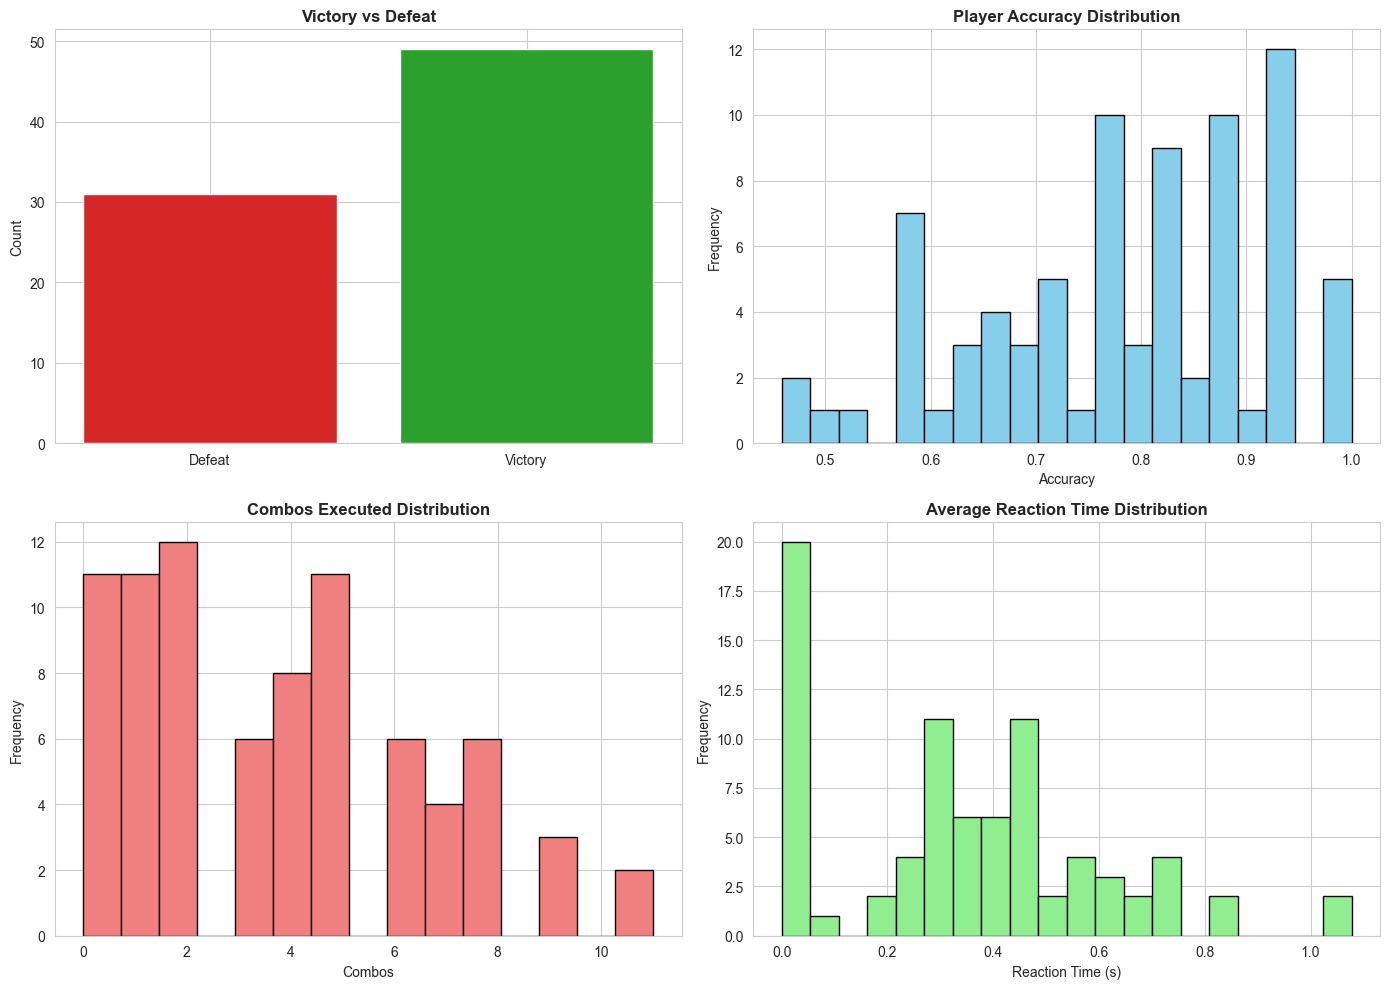

In [29]:
# Fighting game visualizations
if len(fighting_df) > 0 and len(fighting_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Victory distribution
    if 'victory' in fighting_df.columns:
        victory_counts = fighting_df['victory'].value_counts()
        axes[0, 0].bar(['Defeat', 'Victory'], [victory_counts.get(False, 0), victory_counts.get(True, 0)], 
                       color=['#d62728', '#2ca02c'])
        axes[0, 0].set_title('Victory vs Defeat', fontweight='bold')
        axes[0, 0].set_ylabel('Count')
    
    # Accuracy distribution
    if 'playerAccuracy' in fighting_df.columns:
        axes[0, 1].hist(fighting_df['playerAccuracy'].dropna(), bins=20, edgecolor='black', color='skyblue')
        axes[0, 1].set_title('Player Accuracy Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Accuracy')
        axes[0, 1].set_ylabel('Frequency')
    
    # Combos executed
    if 'combosExecuted' in fighting_df.columns:
        axes[1, 0].hist(fighting_df['combosExecuted'].dropna(), bins=15, edgecolor='black', color='lightcoral')
        axes[1, 0].set_title('Combos Executed Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Combos')
        axes[1, 0].set_ylabel('Frequency')
    
    # Reaction time
    if 'avgReactionTime' in fighting_df.columns:
        axes[1, 1].hist(fighting_df['avgReactionTime'].dropna(), bins=20, edgecolor='black', color='lightgreen')
        axes[1, 1].set_title('Average Reaction Time Distribution', fontweight='bold')
        axes[1, 1].set_xlabel('Reaction Time (s)')
        axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

### 4.2 Racing Game Metrics

In [12]:
# Filter racing game data
racing_df = df[df['gameType'] == 'Racing'].copy()

print("RACING GAME ANALYSIS")
print("="*60)
print(f"Total Racing Sessions: {len(racing_df)}")

# Racing-specific metrics
racing_metrics = [col for col in racing_df.columns if col in [
    'lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime',
    'collisions', 'maxSpeed', 'avgSpeed', 'consistency'
]]

if racing_metrics:
    print(f"\nRacing-Specific Metrics: {racing_metrics}")
    print(racing_df[racing_metrics].describe())

RACING GAME ANALYSIS
Total Racing Sessions: 50

Racing-Specific Metrics: ['lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime', 'collisions', 'maxSpeed', 'avgSpeed', 'consistency']
       lapsCompleted  bestLapTime  avgLapTime  totalRaceTime  collisions  \
count      50.000000    50.000000   50.000000      50.000000   50.000000   
mean        2.720000    37.762399   38.469443     110.743796   11.000000   
std         0.783503     8.284017    8.460229      28.066067    7.455993   
min         0.000000     0.000000    0.000000      12.195800    0.000000   
25%         3.000000    38.384945   38.998160     116.289150    5.000000   
50%         3.000000    38.620010   39.506350     117.805800    9.500000   
75%         3.000000    39.245005   39.987400     119.598125   15.750000   
max         3.000000    57.819980   59.311970     177.935900   32.000000   

       maxSpeed   avgSpeed  consistency  
count      50.0  50.000000    50.000000  
mean       40.0  38.044805     0.982176  

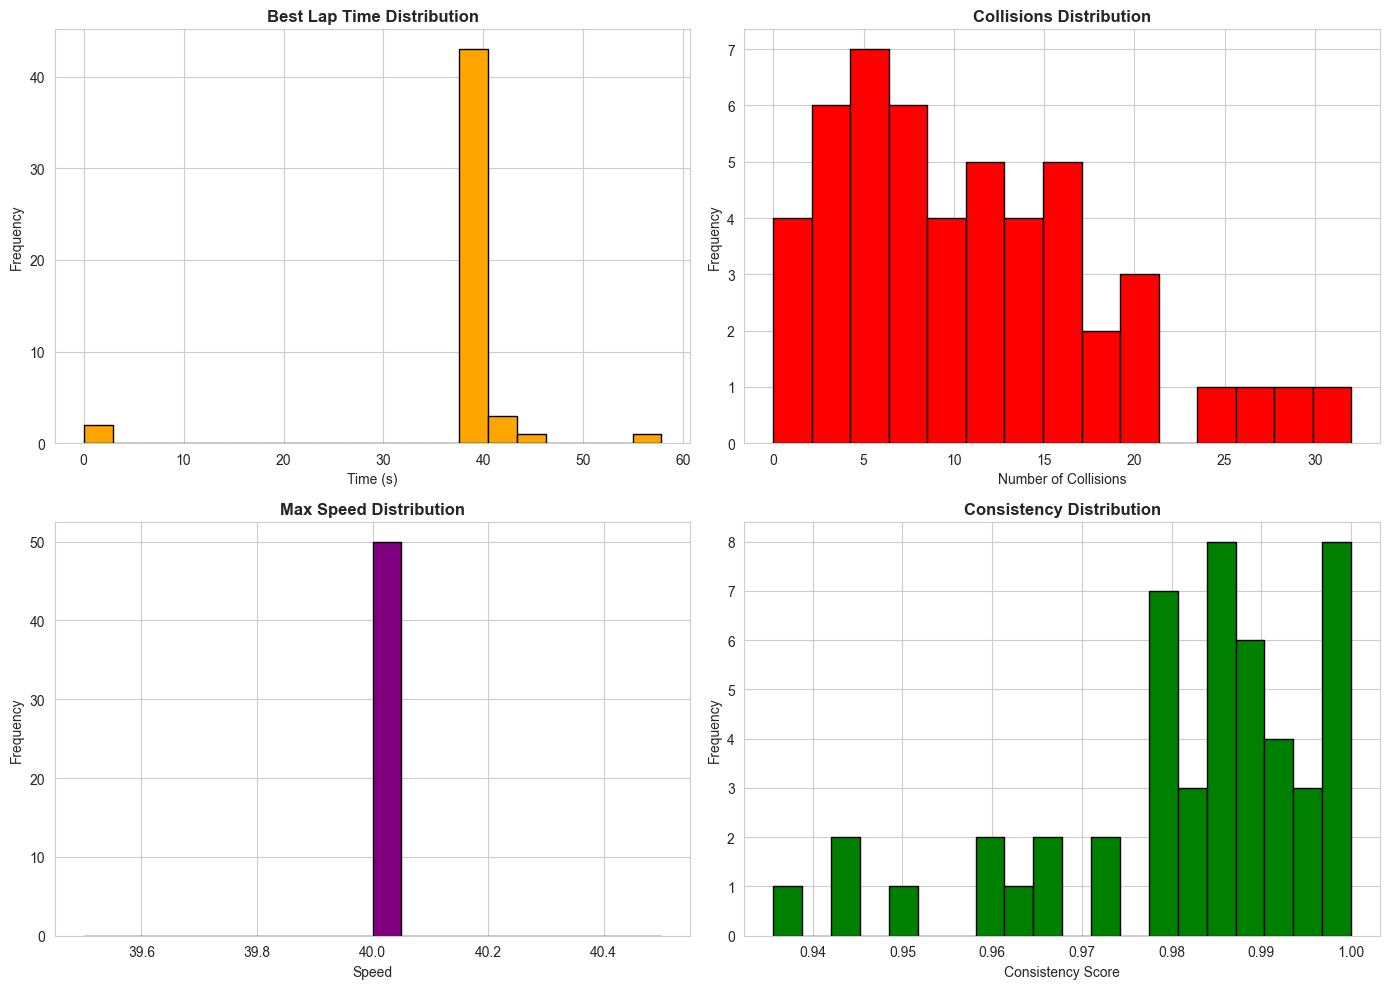

In [30]:
# Racing game visualizations
if len(racing_df) > 0 and len(racing_metrics) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Best lap time distribution
    if 'bestLapTime' in racing_df.columns:
        axes[0, 0].hist(racing_df['bestLapTime'].dropna(), bins=20, edgecolor='black', color='orange')
        axes[0, 0].set_title('Best Lap Time Distribution', fontweight='bold')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('Frequency')
    
    # Collisions distribution
    if 'collisions' in racing_df.columns:
        axes[0, 1].hist(racing_df['collisions'].dropna(), bins=15, edgecolor='black', color='red')
        axes[0, 1].set_title('Collisions Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Number of Collisions')
        axes[0, 1].set_ylabel('Frequency')
    
    # Max speed distribution
    if 'maxSpeed' in racing_df.columns:
        axes[1, 0].hist(racing_df['maxSpeed'].dropna(), bins=20, edgecolor='black', color='purple')
        axes[1, 0].set_title('Max Speed Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Speed')
        axes[1, 0].set_ylabel('Frequency')
    
    # Consistency distribution
    if 'consistency' in racing_df.columns:
        axes[1, 1].hist(racing_df['consistency'].dropna(), bins=20, edgecolor='black', color='green')
        axes[1, 1].set_title('Consistency Distribution', fontweight='bold')
        axes[1, 1].set_xlabel('Consistency Score')
        axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

## 5. Performance Metrics vs Feedback Analysis

**Most Important Section**: Analyzing how performance metrics correlate with user feedback to understand what drives "Too Easy" vs "Too Hard" perceptions.

In [31]:
if 'feedback' in df.columns:
    print("PERFORMANCE METRICS BY FEEDBACK")
    print("="*60)
    
    # Fighting game metrics by feedback
    if len(fighting_df) > 0:
        print("\n--- FIGHTING GAME ---")
        fighting_comparison = fighting_df.groupby('feedback')[fighting_metrics].mean()
        print(fighting_comparison.round(3))
        
        # Statistical tests for key metrics
        if 'playerAccuracy' in fighting_df.columns:
            too_easy = fighting_df[fighting_df['feedback'] == 'TooEasy']['playerAccuracy'].dropna()
            too_hard = fighting_df[fighting_df['feedback'] == 'TooHard']['playerAccuracy'].dropna()
            if len(too_easy) > 0 and len(too_hard) > 0:
                t_stat, p_val = stats.ttest_ind(too_easy, too_hard)
                print(f"\nAccuracy difference: t={t_stat:.3f}, p={p_val:.4f}")
    
    # Racing game metrics by feedback
    if len(racing_df) > 0:
        print("\n--- RACING GAME ---")
        racing_comparison = racing_df.groupby('feedback')[racing_metrics].mean()
        print(racing_comparison.round(3))
        
        # Statistical tests for key metrics
        if 'bestLapTime' in racing_df.columns:
            too_easy = racing_df[racing_df['feedback'] == 'TooEasy']['bestLapTime'].dropna()
            too_hard = racing_df[racing_df['feedback'] == 'TooHard']['bestLapTime'].dropna()
            if len(too_easy) > 0 and len(too_hard) > 0:
                t_stat, p_val = stats.ttest_ind(too_easy, too_hard)
                print(f"\nBest lap time difference: t={t_stat:.3f}, p={p_val:.4f}")

PERFORMANCE METRICS BY FEEDBACK

--- FIGHTING GAME ---
           victory  combosExecuted  perfectDodges  hitsDealt  hitsTaken  \
feedback                                                                  
Balanced  0.722222           3.222          5.556     12.333      7.750   
TooEasy        1.0           7.261          7.435     13.000      1.565   
TooHard        0.0           0.857          0.857      7.238     10.000   

          playerAccuracy  avgReactionTime  
feedback                                   
Balanced           0.760            0.422  
TooEasy            0.895            0.332  
TooHard            0.689            0.222  

Accuracy difference: t=6.128, p=0.0000

--- RACING GAME ---
          lapsCompleted  bestLapTime  avgLapTime  totalRaceTime  collisions  \
feedback                                                                      
Balanced          2.850       36.809      37.554        113.273       9.600   
TooEasy           2.667       36.038      36.527   

C:\Users\Admin\AppData\Local\Temp\ipykernel_27820\721254812.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fighting_df, x='feedback', y='playerAccuracy', ax=axes[0], palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_27820\721254812.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fighting_df, x='feedback', y='avgReactionTime', ax=axes[1], palette='Set2')


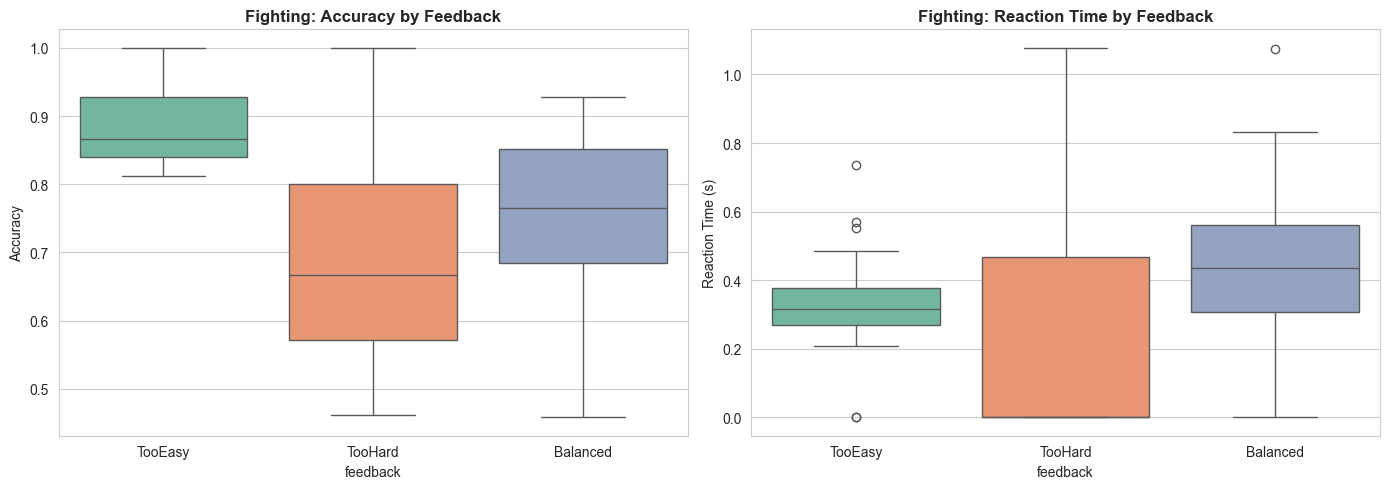

C:\Users\Admin\AppData\Local\Temp\ipykernel_27820\721254812.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=racing_df, x='feedback', y='bestLapTime', ax=axes[0], palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_27820\721254812.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=racing_df, x='feedback', y='collisions', ax=axes[1], palette='Set2')


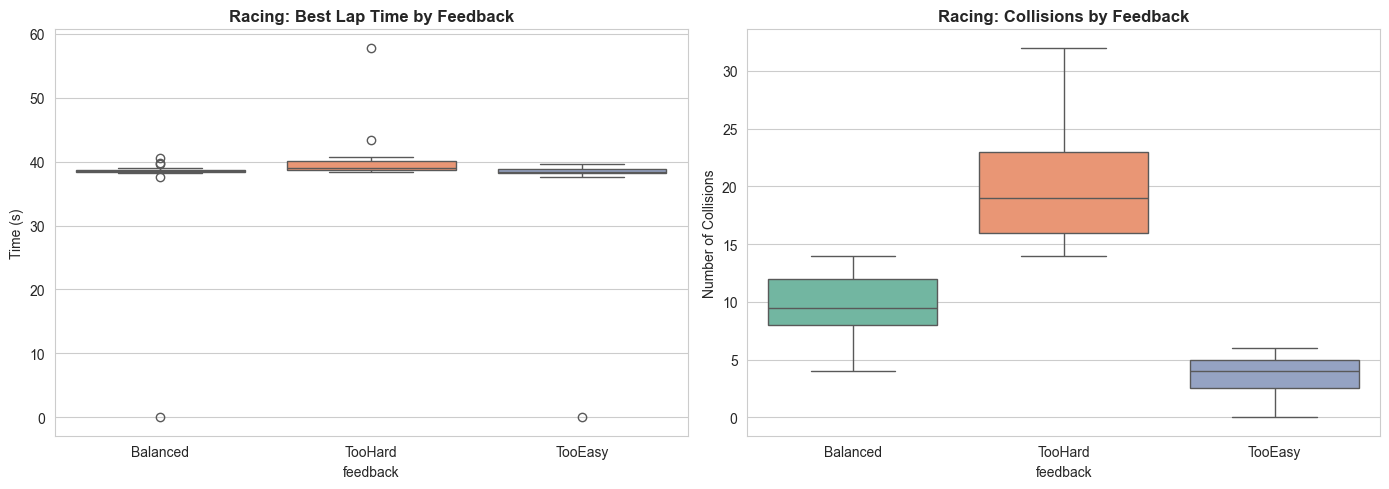

In [32]:
if 'feedback' in df.columns:
    # Fighting game comparison plots
    if len(fighting_df) > 0 and 'playerAccuracy' in fighting_df.columns and 'avgReactionTime' in fighting_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Accuracy by feedback
        sns.boxplot(data=fighting_df, x='feedback', y='playerAccuracy', ax=axes[0], palette='Set2')
        axes[0].set_title('Fighting: Accuracy by Feedback', fontweight='bold')
        axes[0].set_ylabel('Accuracy')
        
        # Reaction time by feedback
        sns.boxplot(data=fighting_df, x='feedback', y='avgReactionTime', ax=axes[1], palette='Set2')
        axes[1].set_title('Fighting: Reaction Time by Feedback', fontweight='bold')
        axes[1].set_ylabel('Reaction Time (s)')
        
        plt.tight_layout()
        plt.show()
    
    # Racing game comparison plots
    if len(racing_df) > 0 and 'bestLapTime' in racing_df.columns and 'collisions' in racing_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Lap time by feedback
        sns.boxplot(data=racing_df, x='feedback', y='bestLapTime', ax=axes[0], palette='Set2')
        axes[0].set_title('Racing: Best Lap Time by Feedback', fontweight='bold')
        axes[0].set_ylabel('Time (s)')
        
        # Collisions by feedback
        sns.boxplot(data=racing_df, x='feedback', y='collisions', ax=axes[1], palette='Set2')
        axes[1].set_title('Racing: Collisions by Feedback', fontweight='bold')
        axes[1].set_ylabel('Number of Collisions')
        
        plt.tight_layout()
        plt.show()

## 6. Feature Correlation Analysis

Identifying which metrics are most strongly associated with feedback labels.

FIGHTING GAME CORRELATIONS WITH FEEDBACK
deaths             0.750068
hitsTaken          0.572748
sessionDuration   -0.100801
avgReactionTime   -0.275779
playerAccuracy    -0.402737
perfectDodges     -0.521843
combosExecuted    -0.601430
score             -0.722390
hitsDealt         -0.864567
lapsCompleted           NaN
bestLapTime             NaN
avgLapTime              NaN
totalRaceTime           NaN
collisions              NaN
maxSpeed                NaN
avgSpeed                NaN
consistency             NaN
Name: feedback_encoded, dtype: float64


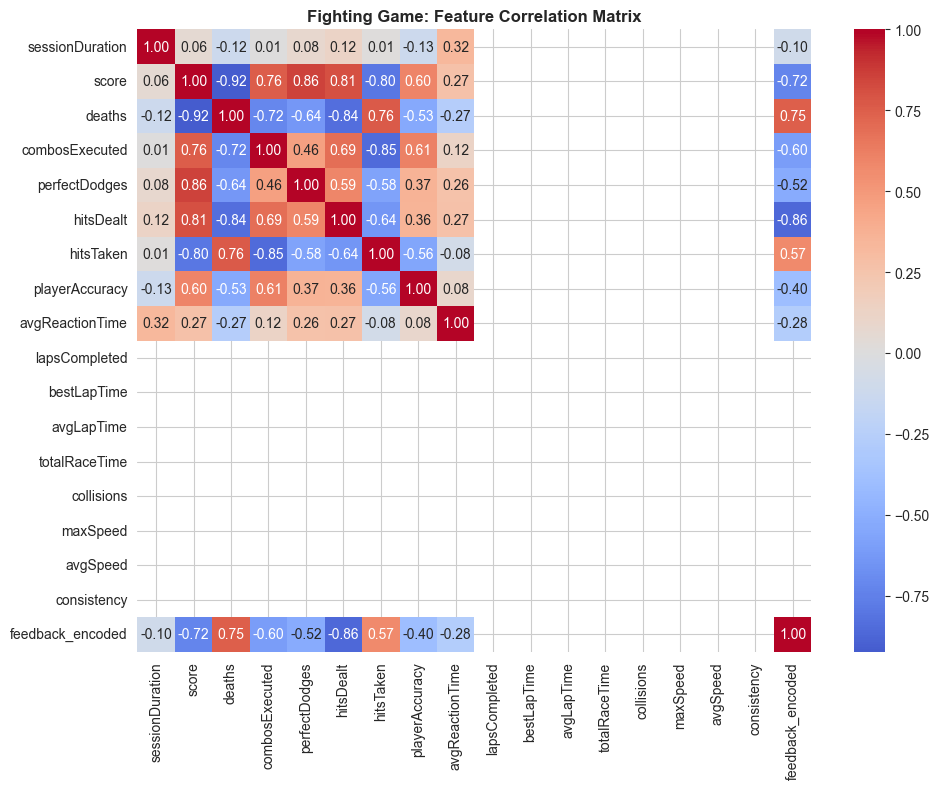


RACING GAME CORRELATIONS WITH FEEDBACK
collisions         0.674696
deaths             0.619935
consistency        0.035944
avgLapTime        -0.388278
bestLapTime       -0.393884
avgSpeed          -0.510127
sessionDuration   -0.521689
totalRaceTime     -0.521691
lapsCompleted     -0.598532
score             -0.890898
combosExecuted          NaN
perfectDodges           NaN
hitsDealt               NaN
hitsTaken               NaN
playerAccuracy          NaN
avgReactionTime         NaN
maxSpeed                NaN
Name: feedback_encoded, dtype: float64


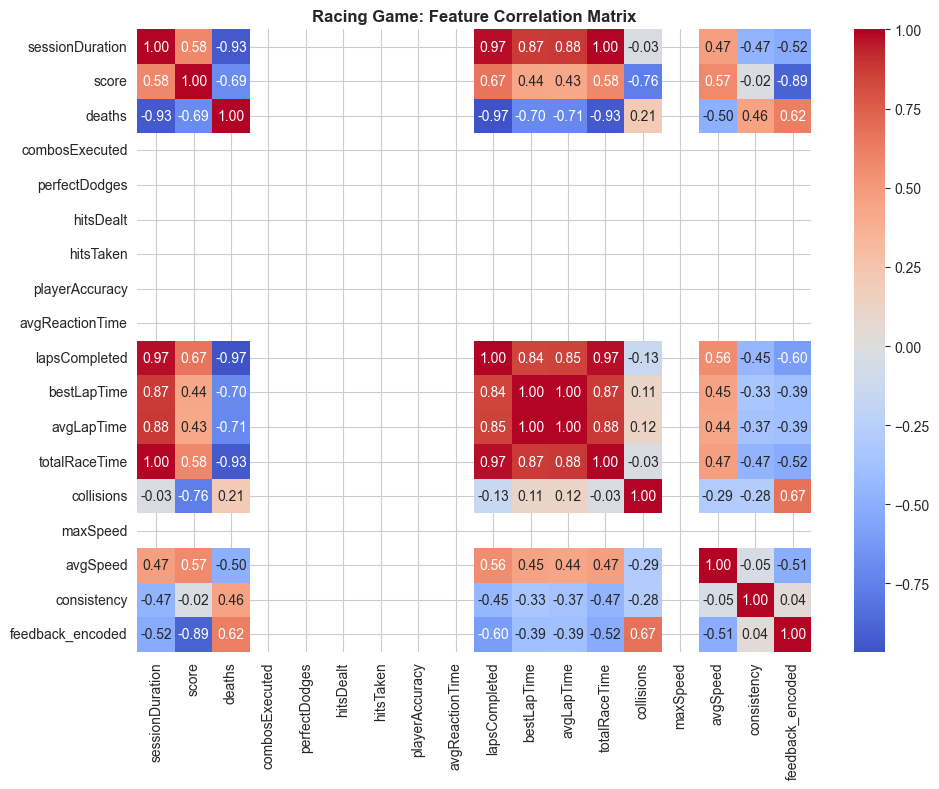

In [33]:
if 'feedback' in df.columns:
    # Encode feedback as binary (0 = TooEasy, 1 = TooHard)
    df_encoded = df.copy()
    df_encoded['feedback_encoded'] = (df_encoded['feedback'] == 'TooHard').astype(int)
    
    # Fighting game correlations
    if len(fighting_df) > 0:
        fighting_encoded = df_encoded[df_encoded['gameType'] == 'Fighting'].copy()
        numeric_cols = fighting_encoded.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [col for col in numeric_cols if col not in ['playerID', 'sessionID']]
        
        if len(numeric_cols) > 2:
            print("FIGHTING GAME CORRELATIONS WITH FEEDBACK")
            print("="*60)
            correlations = fighting_encoded[numeric_cols].corr()['feedback_encoded'].sort_values(ascending=False)
            print(correlations[correlations.index != 'feedback_encoded'])
            
            # Heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(fighting_encoded[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
            plt.title('Fighting Game: Feature Correlation Matrix', fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    # Racing game correlations
    if len(racing_df) > 0:
        racing_encoded = df_encoded[df_encoded['gameType'] == 'Racing'].copy()
        numeric_cols = racing_encoded.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [col for col in numeric_cols if col not in ['playerID', 'sessionID']]
        
        if len(numeric_cols) > 2:
            print("\nRACING GAME CORRELATIONS WITH FEEDBACK")
            print("="*60)
            correlations = racing_encoded[numeric_cols].corr()['feedback_encoded'].sort_values(ascending=False)
            print(correlations[correlations.index != 'feedback_encoded'])
            
            # Heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(racing_encoded[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
            plt.title('Racing Game: Feature Correlation Matrix', fontweight='bold')
            plt.tight_layout()
            plt.show()

## 7. Data Quality Assessment

In [34]:
print("DATA QUALITY SUMMARY")
print("="*60)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check session duration outliers
duration_outliers = df[df['sessionDuration'] > df['sessionDuration'].quantile(0.99)]
print(f"\nSession duration outliers (>99th percentile): {len(duration_outliers)}")

# Check for incomplete sessions
if 'completed' in df.columns:
    incomplete = df[df['completed'] == False]
    print(f"Incomplete sessions: {len(incomplete)} ({len(incomplete)/len(df)*100:.1f}%)")

# Check feedback completeness
if 'feedback' in df.columns:
    missing_feedback = df['feedback'].isnull().sum()
    print(f"\nMissing feedback: {missing_feedback} ({missing_feedback/len(df)*100:.1f}%)")
    if missing_feedback > 0:
        print("⚠️  WARNING: Some sessions missing feedback labels!")
else:
    print("\n⚠️  CRITICAL: No feedback column found!")

# Sample size check
print(f"\nSample Size Assessment:")
print(f"  Total sessions: {len(df)}")
print(f"  Minimum recommended: 180-300 sessions")
if len(df) < 180:
    print(f"  ⚠️  WARNING: Current sample size may be insufficient for robust ML training")
elif len(df) < 300:
    print(f"  ✓ Adequate sample size for initial training")
else:
    print(f"  ✓ Good sample size for robust ML training")

DATA QUALITY SUMMARY
Duplicate rows: 0

Session duration outliers (>99th percentile): 2
Incomplete sessions: 17 (10.6%)

Missing feedback: 0 (0.0%)

Sample Size Assessment:
  Total sessions: 160
  Minimum recommended: 180-300 sessions
  ⚠️  WARNING: Current sample size may be insufficient for robust ML training


## 8. Key Insights & Recommendations for ML Pipeline

### Data Quality Status
- ✅ Check if sample size meets 180-300 target
- ✅ Verify balanced feedback labels (TooEasy vs TooHard)
- ✅ Confirm no missing feedback values

### Feature Engineering Priorities
**Based on correlation analysis above:**

**Fighting Game:**
- Primary features: playerAccuracy, avgReactionTime, combosExecuted
- Secondary features: hitsDealt, hitsTaken, victory

**Racing Game:**
- Primary features: bestLapTime, collisions, avgSpeed
- Secondary features: consistency, maxSpeed, lapsCompleted

### Next Steps
1. **Feature Engineering** - Create normalized/rate-based features
2. **Train/Validation/Test Split** - 70/15/15 split
3. **Model Training** - Separate Random Forest models per game type
4. **Evaluation** - Target F1-score ≥ 0.70 (macro-averaged)
5. **XAI Integration** - Display feature importance to players

### Red Flags to Watch
- Class imbalance > 2:1 ratio
- Missing feedback labels
- Sample size < 180 sessions
- Weak correlations between performance and feedback